# Импорт библиотек

In [18]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import seaborn as sns

# 1)

In [24]:
columns_read = ['Местное время в Перми','T', 'P', 'U', 'Ff', 'N', 'H', 'VV']

df = pd.read_csv('/content/weather1.csv', sep=';', usecols=columns_read)
df

,Местное время в Перми,T,P,U,Ff,N,H,VV
0,31.12.2021 23:00,-9.8,762.5,83,3,100%.,600-1000,4.0
1,31.12.2021 20:00,-10.6,764.2,81,3,100%.,1000-1500,4.0
2,31.12.2021 17:00,-11.6,765.5,79,2,"90 или более, но не 100%",1000-1500,10.0
3,31.12.2021 14:00,-11.9,766.7,77,1,100%.,1000-1500,20.0
4,31.12.2021 11:00,-13.6,767.5,79,1,100%.,1000-1500,10.0
...,...,...,...,...,...,...,...,...
2914,01.01.2021 14:00,-13.0,778.4,82,3,100%.,600-1000,0.5
2915,01.01.2021 11:00,-12.9,778.4,80,4,100%.,600-1000,2.0
2916,01.01.2021 08:00,-12.4,778.3,79,4,100%.,600-1000,10.0
2917,01.01.2021 05:00,-12.3,778.7,80,4,100%.,600-1000,10.0


# 2)

[Text(0.5, 0, 'Температура в цельсиях'),
 Text(0, 0.5, 'Влажность в %'),
 Text(0.5, 1.0, 'Зависимость температуры от влажности')]

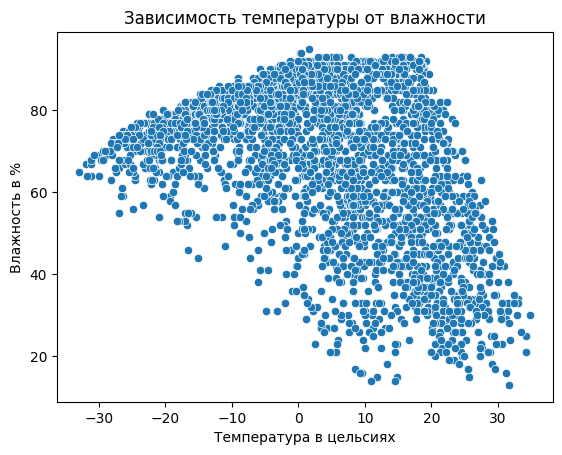

In [8]:
ax2 = sns.scatterplot(data=df, x='T', y='U')
ax2.set(xlabel='Температура в цельсиях', ylabel='Влажность в %', title='Зависимость температуры от влажности')

# 3)

[Text(0.5, 0, 'Температура в цельсиях'),
 Text(0, 0.5, 'Влажность в %'),
 Text(0.5, 1.0, 'Зависимость температуры от влажности c учетом облачности')]

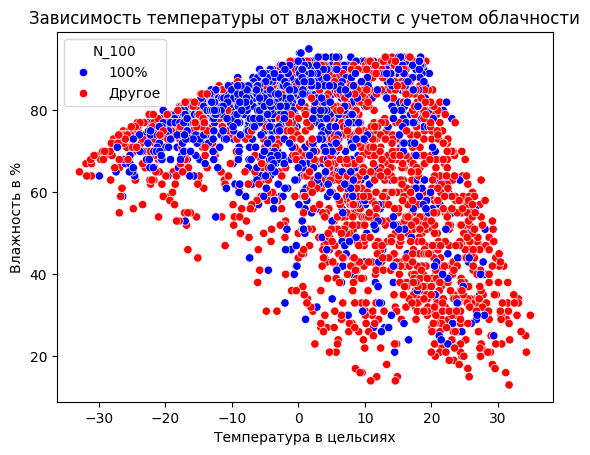

In [68]:
df['N_100'] = np.where(df['N'] == '100%.', '100%', 'Другое')

ax3 = sns.scatterplot(data=df, x='T', y='U', hue = 'N_100', palette={'100%': 'blue', 'Другое': 'red'})
ax3.set(xlabel='Температура в цельсиях', ylabel='Влажность в %', title='Зависимость температуры от влажности c учетом облачности')

# 4)

In [32]:
fig4 = go.Figure()

fig4.add_trace(go.Scatter(x=df['Местное время в Перми'], y=df['T'], mode='lines'))
fig4.update_layout(title='Зависимость температуры от времени', xaxis_title='Дата', yaxis_title='Температура в цельсиях')

fig4.show()

# 5)

In [47]:
df['Местное время в Перми'] = pd.to_datetime(df['Местное время в Перми'])
df['Month'] = df['Местное время в Перми'].dt.month
df_avg_month_temp = df.groupby('Month')['T'].mean()

fig5 = go.Figure()

fig5.add_trace(go.Bar(x=df_avg_month_temp.index, y=df_avg_month_temp.values))
fig5.update_layout(width=1000, height=600, title='Среднемесячная температура за месяц', xaxis_title='Дата', yaxis_title='Температура в цельсиях')

fig5.show()

# 6)

In [56]:
N_count = df['N'].value_counts()

fig6 = go.Figure()

fig6.add_trace(go.Bar(y=N_count.index, x=N_count.values, orientation='h'))
fig6.update_layout(width=1500, height=600, title='Кол-во наблюдений для каждой категории облачности', xaxis_title='Кол-во', yaxis_title='Категория')

fig6.show()


# 7)

[Text(0.5, 0, 'Температура в цельсиях'),
 Text(0, 0.5, 'Кол-во наблюдений'),
 Text(0.5, 1.0, 'Распределение температуры')]

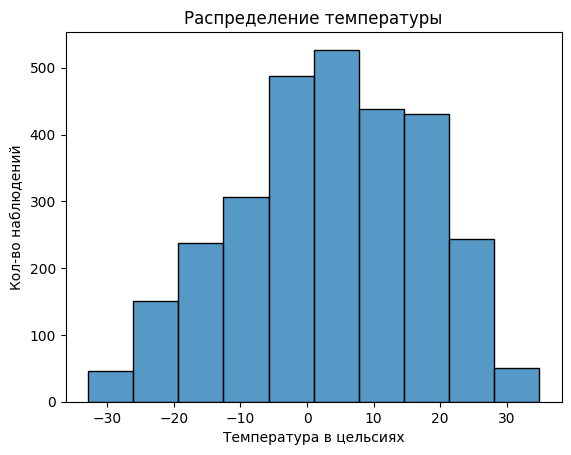

In [58]:
ax7 = sns.histplot(data=df, x='T', bins=10)
ax7.set(xlabel='Температура в цельсиях', ylabel='Кол-во наблюдений', title='Распределение температуры')

# 8)

[Text(0.5, 0, 'Дальность видимости'),
 Text(0, 0.5, 'Атмосферное давление в мм.рт.ст.'),
 Text(0.5, 1.0, 'Распределение атмосферного давление по видимости')]

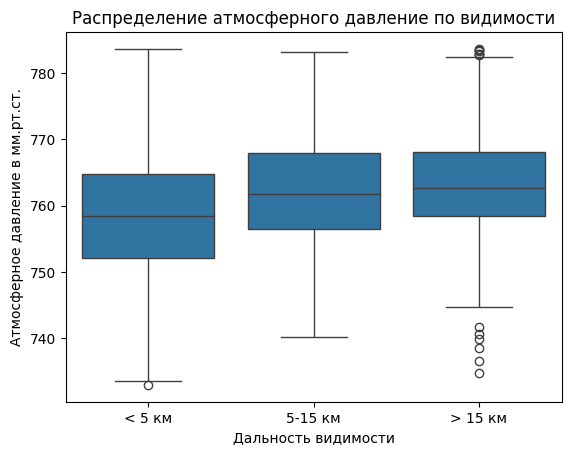

In [69]:
df['VV_category'] = pd.cut(df['VV'], bins=[-np.inf, 5, 15, np.inf], labels=['< 5 км', '5-15 км', '> 15 км'])

ax8 = sns.boxplot(data=df, x='VV_category', y='P')
ax8.set(xlabel='Дальность видимости', ylabel='Атмосферное давление в мм.рт.ст.', title='Распределение атмосферного давление по видимости')

# 9)

In [75]:
h_counts = df['H'].value_counts()

fig9 = go.Figure(data=[go.Pie(labels=h_counts.index, values=h_counts.values, hole=0, textinfo='percent+label')])
fig9.update_layout(width=1000, height=600, title='Распределение высоты для облаков')

fig9.show()